In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp


In [29]:
def p(x):
    return -np.tan(x)

def q(x):
    return x

def f(x):
    return np.cos(x)

## Метод кінцевих різниць для крайової задачі


### задача:



рівняння:
$$
y'' + p(x)y' + q(x)y = f(x)
$$

Граничні умови:
$$
y(a) = \alpha, \quad y(b) = \beta
$$


### дискретизація

Інтервал дискретизації:

$$
x_i = a + i \cdot h, \quad i = 0, 1, \ldots, n-1, \quad h = \frac{b-a}{n-1}
$$

#### Кінцево-різнична схема

формула другої похідної:
$$
y''(x_i) \approx \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2}
$$

формула першої похідної з центральної різниці:
$$
y'(x_i) \approx \frac{y_{i+1} - y_{i-1}}{2h}
$$

Підстановка в рівняння:
$$
\frac{y_{i-1} - 2y_i + y_{i+1}}{h^2} + p(x_i) \cdot \frac{y_{i+1} - y_{i-1}}{2h} + q(x_i) y_i = f(x_i)
$$

#### Система рівнянь

Для внутрішніх точок $i = 1, 2, \ldots, n-2$:

$$
\left( \frac{1}{h^2} - \frac{p(x_i)}{2h} \right) y_{i-1} + \left( -\frac{2}{h^2} + q(x_i) \right) y_i + \left( \frac{1}{h^2} + \frac{p(x_i)}{2h} \right) y_{i+1} = f(x_i)
$$

Коефіцієнти тридіагональної матриці:
$$
\begin{aligned}
коефіцієнт при y_ {i-1} : a_i &= \frac{1}{h^2} - \frac{p(x_i)}{2h} \\ 
b_i &= -\frac{2}{h^2} + q(x_i) \\
c_i &= \frac{1}{h^2} + \frac{p(x_i)}{2h} \\
d_i &= f(x_i) права частина 
\end{aligned}
$$



$$
\mathbf{y} = [\alpha, y_1, y_2, \ldots, y_{n-2}, \beta]^T
$$


### Алгоритм Томаса



**Прямий хід:**
$$
\begin{aligned}
c_1' &= \frac{c_1}{b_1} \\
d_1' &= \frac{d_1}{b_1} \\
c_i' &= \frac{c_i}{b_i - a_{i-1}c_{i-1}'}, \quad i = 2, 3, \ldots, n-3 \\
d_i' &= \frac{d_i - a_{i-1}d_{i-1}'}{b_i - a_{i-1}c_{i-1}'}, \quad i = 2, 3, \ldots, n-2
\end{aligned}
$$

**Зворотний хід:**
$$
\begin{aligned}
y_{n-2} &= d_{n-2}' \\
y_i &= d_i' - c_i' y_{i+1}, \quad i = n-3, n-4, \ldots, 1
\end{aligned}
$$

## Реалізація

In [30]:
def solve_bvp_finite_difference(p, q, f, a, b, alpha, beta, n):
    h = (b - a) / (n - 1)
    x = np.linspace(a, b, n)
    
    a_diag = np.zeros(n-2)
    b_diag = np.zeros(n-2)
    c_diag = np.zeros(n-2)
    right_new = np.zeros(n-2)
    
    for i in range(1, n-1):
        idx = i - 1
        x_i = x[i]
        
        a_diag[idx] = 1/h**2 - p(x_i)/(2*h)
        b_diag[idx] = -2/h**2 + q(x_i)
        c_diag[idx] = 1/h**2 + p(x_i)/(2*h)
        right_new[idx] = f(x_i)
    
    right_new[0] -= a_diag[0] * alpha
    right_new[-1] -= c_diag[-1] * beta

    n_inner = n - 2
    y_inner = np.zeros(n_inner)

    A = np.zeros((n_inner, n_inner))

    for i in range(n_inner):
        if i > 0:
            A[i, i-1] = a_diag[i]
        A[i, i] = b_diag[i]
        if i < n_inner-1:
            A[i, i+1] = c_diag[i]
    
    y_inner = np.linalg.solve(A, right_new)
    
    y = np.zeros(n)
    y[0] = alpha
    y[-1] = beta
    y[1:-1] = y_inner
    
    return x, y

In [31]:
a, b = 0, np.pi/4
alpha, beta = 0, 1
n = 200

x_thomas, y_thomas = solve_bvp_finite_difference(p, q, f, a, b, alpha, beta, n)

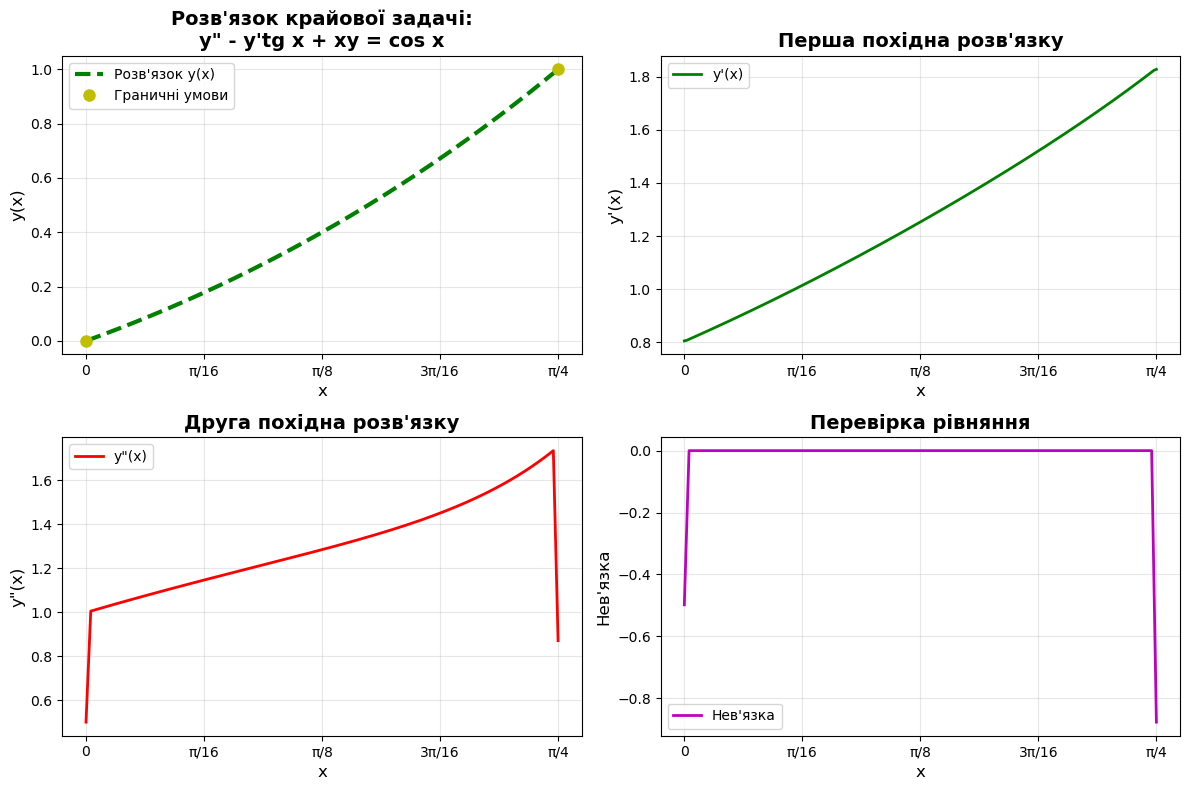

In [51]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(x_thomas, y_thomas, 'g--', linewidth=3, label='Розв\'язок y(x)')
plt.plot([a, b], [alpha, beta], 'yo', markersize=8, label='Граничні умови')
plt.xlabel('x', fontsize=12)
plt.ylabel('y(x)', fontsize=12)
plt.title('Розв\'язок крайової задачі:\ny" - y\'tg x + xy = cos x', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xticks([0, np.pi/16, np.pi/8, 3*np.pi/16, np.pi/4], 
           ['0', 'π/16', 'π/8', '3π/16', 'π/4'])

plt.subplot(2, 2, 2)
y_prime = np.gradient(y_thomas, x_thomas)
plt.plot(x_thomas, y_prime, 'g-', linewidth=2, label="y'(x)")
plt.xlabel('x', fontsize=12)
plt.ylabel("y'(x)", fontsize=12)
plt.title('Перша похідна розв\'язку', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xticks([0, np.pi/16, np.pi/8, 3*np.pi/16, np.pi/4], 
           ['0', 'π/16', 'π/8', '3π/16', 'π/4'])

plt.subplot(2, 2, 3)
y_double_prime = np.gradient(y_prime, x_thomas)
plt.plot(x_thomas, y_double_prime, 'r-', linewidth=2, label='y"(x)')
plt.xlabel('x', fontsize=12)
plt.ylabel('y"(x)', fontsize=12)

plt.title('Друга похідна розв\'язку', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xticks([0, np.pi/16, np.pi/8, 3*np.pi/16, np.pi/4], 
           ['0', 'π/16', 'π/8', '3π/16', 'π/4'])

plt.subplot(2, 2, 4)
residual = y_double_prime - np.tan(x_thomas) * y_prime + x_thomas * y_thomas - np.cos(x_thomas)
plt.plot(x_thomas, residual, 'm-', linewidth=2, label='Нев\'язка')
plt.xlabel('x', fontsize=12)
plt.ylabel('Нев\'язка', fontsize=12)
plt.title('Перевірка рівняння', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xticks([0, np.pi/16, np.pi/8, 3*np.pi/16, np.pi/4], 
           ['0', 'π/16', 'π/8', '3π/16', 'π/4'])

plt.tight_layout()
plt.show()

In [36]:
print(f"Мінімальне значення y(x): {np.min(y_thomas):.6f}")
print(f"Максимальне значення y(x): {np.max(y_thomas):.6f}")
print(f"Середнє значення y(x): {np.mean(y_thomas):.6f}")
print(f"Максимальна нев'язка: {np.max(np.abs(residual)):.2e}")

Мінімальне значення y(x): 0.000000
Максимальне значення y(x): 1.000000
Середнє значення y(x): 0.433586
Максимальна нев'язка: 8.78e-01


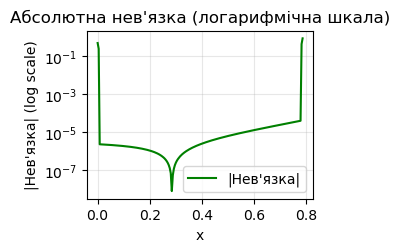

In [53]:
def calculate_residual(x, y):
    y_prime = np.gradient(y, x)
    y_double_prime = np.gradient(y_prime, x)
    
    residual = y_double_prime - np.tan(x) * y_prime + x * y - np.cos(x)
    
    return residual
residual = calculate_residual(x_thomas, y_thomas)


plt.subplot(2, 2, 3)
plt.semilogy(x_thomas, np.abs(residual), 'g-', linewidth=1.5, label='|Нев\'язка|')
plt.xlabel('x')
plt.ylabel('|Нев\'язка| (log scale)')
plt.title('Абсолютна нев\'язка (логарифмічна шкала)')
plt.grid(True, alpha=0.3)
plt.legend()